In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("ML libraries imported successfully!")

ML libraries imported successfully!


In [4]:
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")

print(df.shape)
print(df.head())

(7043, 20)
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes   

In [5]:
# Separate features and target

X = df.drop(columns=["Churn"])
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [7]:
# Check current feature columns
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [8]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 19)
X_test : (1409, 19)
y_train: (5634,)
y_test : (1409,)


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:")
print(categorical_cols.tolist())

print("\nNumerical columns:")
print(numerical_cols.tolist())

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


C:\Users\hp\AppData\Local\Temp\ipykernel_15184\39936243.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (5634, 45)
Processed testing shape : (1409, 45)


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_processed, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [13]:
# Make predictions on test data
y_pred = model.predict(X_test_processed)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
First 20 predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Model Evaluation
-----------------
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.6040


Confusion Matrix:
[[926 109]
 [165 209]]


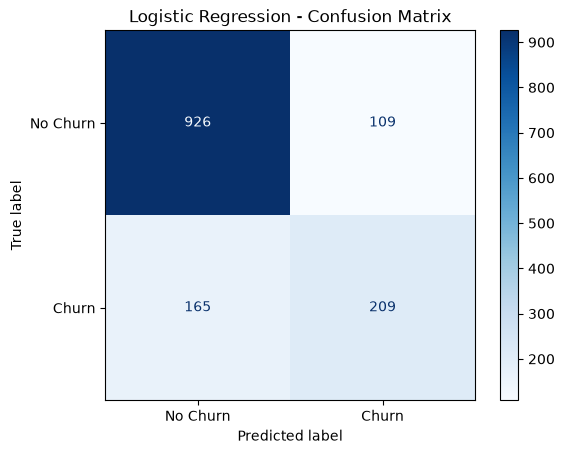

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [16]:
from sklearn.metrics import classification_report

print("Classification Report")
print("---------------------")

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

Classification Report
---------------------
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest training completed successfully!")

Random Forest training completed successfully!


In [18]:
# Make predictions using Random Forest

rf_pred = rf_model.predict(X_test_processed)

print("Random Forest predictions generated successfully!")
print("First 20 predictions:")
print(rf_pred[:20])

Random Forest predictions generated successfully!
First 20 predictions:
[0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Evaluation")
print("------------------------")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

Random Forest Evaluation
------------------------
Accuracy  : 0.7835
Precision : 0.6186
Recall    : 0.4813
F1 Score  : 0.5414


In [20]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")
print("------------------------------------")

print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Churn", "Churn"]
))

Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



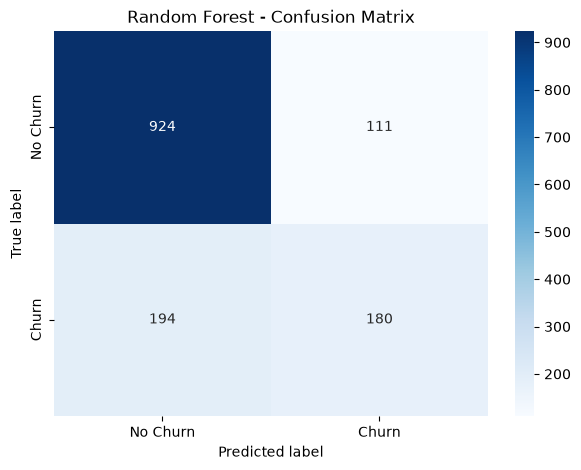

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [22]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "Precision": [precision, rf_precision],
    "Recall": [recall, rf_recall],
    "F1 Score": [f1, rf_f1]
})

print(model_comparison.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.8055     0.6572  0.5588    0.6040
1        Random Forest    0.7835     0.6186  0.4813    0.5414


In [23]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "Precision": [precision, rf_precision],
    "Recall": [recall, rf_recall],
    "F1 Score": [f1, rf_f1]
})

print(model_comparison.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.8055     0.6572  0.5588    0.6040
1        Random Forest    0.7835     0.6186  0.4813    0.5414


In [24]:
from sklearn.linear_model import LogisticRegression

# Train balanced Logistic Regression
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(X_train_processed, y_train)

print("Balanced Logistic Regression training completed successfully!")

Balanced Logistic Regression training completed successfully!


In [25]:
# Make predictions using balanced Logistic Regression
balanced_pred = balanced_model.predict(X_test_processed)

print("Balanced Logistic Regression predictions generated successfully!")
print("First 20 predictions:")
print(balanced_pred[:20])

Balanced Logistic Regression predictions generated successfully!
First 20 predictions:
[0 1 0 1 0 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0]


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

balanced_accuracy = accuracy_score(y_test, balanced_pred)
balanced_precision = precision_score(y_test, balanced_pred)
balanced_recall = recall_score(y_test, balanced_pred)
balanced_f1 = f1_score(y_test, balanced_pred)

print("Balanced Logistic Regression Evaluation")
print("---------------------------------------")
print(f"Accuracy  : {balanced_accuracy:.4f}")
print(f"Precision : {balanced_precision:.4f}")
print(f"Recall    : {balanced_recall:.4f}")
print(f"F1 Score  : {balanced_f1:.4f}")

Balanced Logistic Regression Evaluation
---------------------------------------
Accuracy  : 0.7381
Precision : 0.5043
Recall    : 0.7834
F1 Score  : 0.6136


In [27]:
from sklearn.metrics import classification_report

print("Balanced Logistic Regression Classification Report")
print("---------------------------------------------------")

print(classification_report(
    y_test,
    balanced_pred,
    target_names=["No Churn", "Churn"]
))

Balanced Logistic Regression Classification Report
---------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



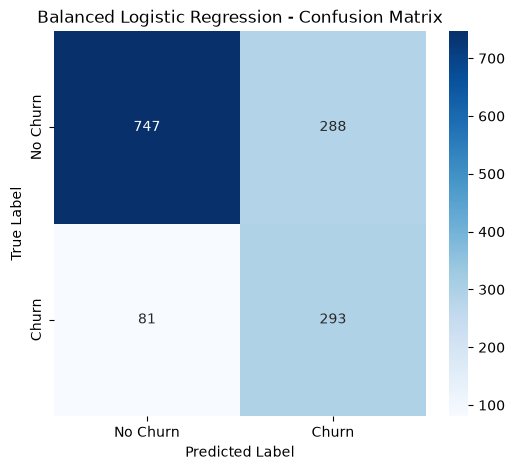

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_balanced = confusion_matrix(y_test, balanced_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Balanced Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [29]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        balanced_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        balanced_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        balanced_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        balanced_f1
    ]
})

print(final_comparison.round(4))

                          Model  Accuracy  Precision  Recall  F1 Score
0           Logistic Regression    0.8055     0.6572  0.5588    0.6040
1                 Random Forest    0.7835     0.6186  0.4813    0.5414
2  Balanced Logistic Regression    0.7381     0.5043  0.7834    0.6136


In [30]:
from sklearn.metrics import roc_auc_score

# Get churn probabilities
balanced_prob = balanced_model.predict_proba(X_test_processed)[:, 1]

# Calculate ROC-AUC
balanced_auc = roc_auc_score(y_test, balanced_prob)

print("Balanced Logistic Regression ROC-AUC")
print("------------------------------------")
print(f"ROC-AUC Score : {balanced_auc:.4f}")

Balanced Logistic Regression ROC-AUC
------------------------------------
ROC-AUC Score : 0.8416


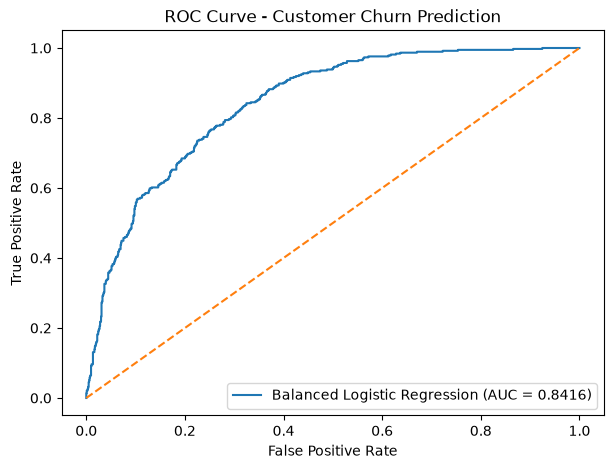

In [31]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, balanced_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Balanced Logistic Regression (AUC = {balanced_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.show()

In [32]:
# ROC-AUC for the other models

lr_prob = model.predict_proba(X_test_processed)[:, 1]
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

lr_auc = roc_auc_score(y_test, lr_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Model ROC-AUC Comparison")
print("------------------------")
print(f"Logistic Regression          : {lr_auc:.4f}")
print(f"Random Forest                : {rf_auc:.4f}")
print(f"Balanced Logistic Regression : {balanced_auc:.4f}")

Model ROC-AUC Comparison
------------------------
Logistic Regression          : 0.8421
Random Forest                : 0.8206
Balanced Logistic Regression : 0.8416


In [33]:
final_comparison["ROC-AUC"] = [
    lr_auc,
    rf_auc,
    balanced_auc
]

print(final_comparison.round(4))

                          Model  Accuracy  Precision  Recall  F1 Score  \
0           Logistic Regression    0.8055     0.6572  0.5588    0.6040   
1                 Random Forest    0.7835     0.6186  0.4813    0.5414   
2  Balanced Logistic Regression    0.7381     0.5043  0.7834    0.6136   

   ROC-AUC  
0   0.8421  
1   0.8206  
2   0.8416  


In [34]:
from sklearn.pipeline import Pipeline

# Create final pipeline
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", balanced_model)
])

print("Final model pipeline created successfully!")

Final model pipeline created successfully!


In [35]:
# Test final pipeline
final_pred = final_model.predict(X_test)

print("Final pipeline testing completed successfully!")
print("First 20 predictions:")
print(final_pred[:20])

Final pipeline testing completed successfully!
First 20 predictions:
[0 1 0 1 0 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0]


In [36]:
import joblib

# Save the complete model pipeline
joblib.dump(final_model, "customer_churn_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [38]:
import joblib

# Get column names directly from X_train
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Store feature information
feature_info = {
    "categorical_columns": categorical_cols,
    "numeric_columns": numeric_cols
}

# Save feature information
joblib.dump(feature_info, "feature_info.pkl")

print("Feature information saved successfully!")
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Feature information saved successfully!
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


C:\Users\hp\AppData\Local\Temp\ipykernel_15184\3264919402.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


In [39]:
# Create a sample new customer

new_customer = pd.DataFrame([{
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.0,
    "TotalCharges": 425.0
}])

print("New customer created successfully!")
print(new_customer)

New customer created successfully!
  gender  SeniorCitizen Partner Dependents  tenure PhoneService MultipleLines  \
0   Male              0     Yes         No       5          Yes            No   

  InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport  \
0     Fiber optic             No           No               No          No   

  StreamingTV StreamingMovies        Contract PaperlessBilling  \
0         Yes             Yes  Month-to-month              Yes   

      PaymentMethod  MonthlyCharges  TotalCharges  
0  Electronic check            85.0         425.0  


In [40]:
# Predict churn for the new customer

prediction = final_model.predict(new_customer)[0]
probability = final_model.predict_proba(new_customer)[0][1]

print("Customer Churn Prediction")
print("-------------------------")

if prediction == 1:
    print("Prediction: CHURN")
else:
    print("Prediction: NO CHURN")

print(f"Churn Probability: {probability:.2%}")

Customer Churn Prediction
-------------------------
Prediction: CHURN
Churn Probability: 91.06%


In [41]:
# Convert churn probability into risk level

if probability < 0.30:
    risk_level = "Low Risk"
elif probability < 0.70:
    risk_level = "Medium Risk"
else:
    risk_level = "High Risk"

print("Customer Risk Assessment")
print("------------------------")
print(f"Churn Probability : {probability:.2%}")
print(f"Risk Level        : {risk_level}")

Customer Risk Assessment
------------------------
Churn Probability : 91.06%
Risk Level        : High Risk


In [42]:
# Generate business recommendation based on risk level

if risk_level == "High Risk":
    recommendation = [
        "Contact the customer immediately",
        "Offer a personalized retention discount",
        "Provide technical/customer support",
        "Consider a suitable plan upgrade or incentive"
    ]

elif risk_level == "Medium Risk":
    recommendation = [
        "Send a targeted retention offer",
        "Monitor customer activity",
        "Improve customer engagement"
    ]

else:
    recommendation = [
        "No immediate retention action required",
        "Continue regular customer engagement"
    ]

print("Customer Retention Recommendation")
print("---------------------------------")
print(f"Risk Level: {risk_level}")
print("\nRecommended Actions:")

for action in recommendation:
    print(f"- {action}")

Customer Retention Recommendation
---------------------------------
Risk Level: High Risk

Recommended Actions:
- Contact the customer immediately
- Offer a personalized retention discount
- Provide technical/customer support
- Consider a suitable plan upgrade or incentive


In [43]:
import joblib

# Save the final model
joblib.dump(final_model, "customer_churn_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [44]:
# Save the preprocessing pipeline

joblib.dump(preprocessor, "preprocessor.pkl")

print("Preprocessing pipeline saved successfully!")

Preprocessing pipeline saved successfully!


In [45]:
import joblib

# Load saved model and preprocessing pipeline
loaded_model = joblib.load("customer_churn_model.pkl")
loaded_preprocessor = joblib.load("preprocessor.pkl")

print("Saved model loaded successfully!")
print("Preprocessor loaded successfully!")

Saved model loaded successfully!
Preprocessor loaded successfully!


In [47]:
# Test the saved model correctly

loaded_prediction = loaded_model.predict(new_customer)[0]

loaded_probability = loaded_model.predict_proba(new_customer)[0][1]

print("Loaded Model Prediction")
print("----------------------")

if loaded_prediction == 1:
    print("Prediction: CHURN")
else:
    print("Prediction: NO CHURN")

print(f"Churn Probability: {loaded_probability:.2%}")

Loaded Model Prediction
----------------------
Prediction: CHURN
Churn Probability: 91.06%
